# 📚 Study Hours vs Exam Score — Simple Linear Regression

**Dataset :** 200 students — how many hours they studied and what score they got

**Input (X) :** `Study_Hours` — how many hours a student studied

**Output (Y) :** `Exam_Score` — score they got in the exam

---

## 🗺️ Pipeline

| Step | Task |
|------|------|
| 1 | Load + Basic Look |
| 2 | EDA — Scatter + Correlation |
| 3 | Split X and Y |
| 4 | Train Test Split |
| 5 | Standardization (Z-Score) |
| 6 | Apply Simple Linear Regression |
| 7 | Plot Best Fit Line |
| 8 | Predictions |
| 9 | Performance Metrics (MAE, MSE, RMSE) |
| 10 | R² and Adjusted R² |

---

## 📦 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

---
## Step 1 — Load Dataset + Basic Look

In [2]:
df = pd.read_csv("study_score.csv")
df.head()
# see it has one input feature and one output feature so simple linear regression

,Study_Hours,Exam_Score
0,4.1,53.2
1,9.5,92.9
2,7.5,80.2
3,6.2,66.7
4,2.0,52.3


In [3]:
df.tail()

,Study_Hours,Exam_Score
195,3.8,47.7
196,7.4,74.5
197,9.0,87.4
198,8.9,89.4
199,7.9,88.7


In [4]:
# Basic Info
df.shape

(200, 2)

In [5]:
# Check dtypes and null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study_Hours  200 non-null    float64
 1   Exam_Score   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [6]:
# Statistical summary
df.describe()

,Study_Hours,Exam_Score
count,200.000000,200.000000
mean,5.100000,63.479500
std,2.797917,18.702203
min,0.600000,28.200000
25%,2.700000,46.875000
50%,5.200000,62.000000
75%,7.700000,80.050000
max,9.900000,100.000000


In [7]:
# Check missing values
df.isnull().sum()
# Simple dataset — no nulls expected

Study_Hours    0
Exam_Score     0
dtype: int64

---
## Step 2 — EDA

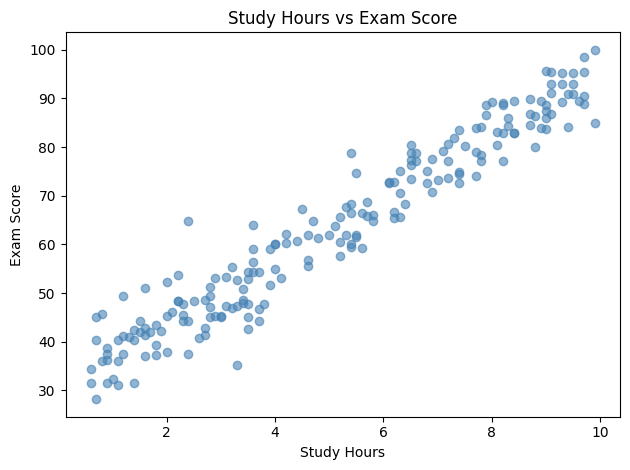

In [8]:
# Scatter plot to see correlation
# more study hours → higher score ?

plt.scatter(df["Study_Hours"], df["Exam_Score"], color="steelblue", alpha=0.6)
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")
plt.tight_layout()
plt.show()

In [9]:
# See correlation using corr()
df.corr()

# Study_Hours x Exam_Score should be close to 1 (highly positive correlated)
# means as study hours increase, exam score also increases

,Study_Hours,Exam_Score
Study_Hours,1.000000,0.965912
Exam_Score,0.965912,1.000000


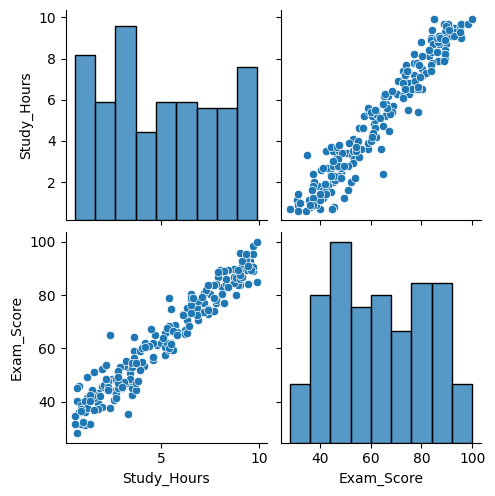

In [10]:
# Pairplot for full visual overview
sns.pairplot(df)

---
## Step 3 — Split X and Y

    Independent Feature (X) must be in the form of DataFrame or 2D Array
    Dependent Feature (Y) can be a Series or 1D

---
### Rule

    Independent Feature must be in the form of DataFrame or 2D array
    Use double brackets [[ ]] to keep it as DataFrame

In [13]:
X = df[["Study_Hours"]]   # double bracket -> DataFrame -> correct
type(X)

pandas.DataFrame

In [14]:
X.head(3)

,Study_Hours
0,4.1
1,9.5
2,7.5


---

    Dependent Feature Y can be Series or 1D — that is fine

In [15]:
Y = df["Exam_Score"]    # single bracket -> Series -> fine for Y
type(Y)

pandas.Series

---

    Summary :
    X  →  double bracket  →  DataFrame  →  Independent Feature
    Y  →  single bracket  →  Series    →  Dependent Feature

In [16]:
# Final clean assignment
X = df[["Study_Hours"]]   # Independent Feature (Input)
Y = df["Exam_Score"]      # Dependent Feature  (Output / Target)

---
## Step 4 — Train Test Split

    Train Data  →  Model learns from this
    Test Data   →  Model is evaluated on this (never seen during training)

    test_size = 0.25  means  75% train  and  25% test

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.25,
    random_state=42
)

In [19]:
# Verify sizes
print("X_train shape :", X_train.shape)
print("X_test  shape :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test  shape :", y_test.shape)

X_train shape : (150, 1)
X_test  shape : (50, 1)
y_train shape : (150,)
y_test  shape : (50,)


---
## Step 5 — Standardization ( Z-Score )

- Z-Score converts different units into one standard unit
- Formula :  z = ( x − mean ) / std
- After scaling : mean becomes 0 and std becomes 1

    Why only X and not Y ?
    We only scale the Input Features
    The output Y stays in its original unit (exam score in marks)

    Why fit_transform on X_train but only transform on X_test ?
    fit_transform  →  learns mean and std from training data  +  applies formula
    transform      →  uses the SAME mean and std already learned  →  applies formula only
    
    If we fit on X_test too →  data leakage  →  model sees exam answers before the exam

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()   # loads Z-Score formula :  z = x − mean / std

# fit_transform on training data
# fit   : learn mean and std from X_train
# transform : apply Z-Score using that mean and std

X_train = scaler.fit_transform(X_train)
X_train

array([[ 0.49195021],
       [-0.8626953 ],
       [-1.11223527],
       [ 1.13362441],
       [-1.00528957],
       [ 1.09797584],
       [ 1.59705577],
       [-1.57566663],
       [ 0.09981599],
       [ 0.13546455],
       [ 0.34935595],
       [-0.18537254],
       [-1.0765867 ],
       [ 1.16927297],
       [ 1.09797584],
       [ 0.17111312],
       [-1.54001806],
       [-0.82704674],
       [-1.25482953],
       [ 0.09981599],
       [ 0.99103014],
       [ 1.27621867],
       [ 0.49195021],
       [ 0.02851885],
       [ 1.38316437],
       [ 1.09797584],
       [-0.969641  ],
       [ 1.63270433],
       [-1.54001806],
       [-1.11223527],
       [ 0.84843588],
       [-1.3974238 ],
       [-0.57750677],
       [ 0.24241025],
       [ 1.38316437],
       [-0.54185821],
       [ 0.49195021],
       [-0.61315534],
       [-1.32612666],
       [-0.72010104],
       [-0.6488039 ],
       [-0.79139817],
       [ 0.49195021],
       [ 1.5614072 ],
       [ 1.63270433],
       [-0

In [22]:
# only transform on test data
# scaler already knows mean and std from X_train
# we just apply the same formula to X_test

X_test = scaler.transform(X_test)
X_test

array([[ 0.02851885],
       [-1.04093813],
       [ 0.42065308],
       [-0.82704674],
       [-1.61131519],
       [ 1.31186724],
       [ 1.70400146],
       [ 0.63454448],
       [ 0.52759878],
       [ 0.59889591],
       [-1.1835324 ],
       [ 1.49011007],
       [ 1.16927297],
       [-0.43491251],
       [ 1.13362441],
       [-0.32796681],
       [-1.36177523],
       [-1.14788383],
       [-0.54185821],
       [-1.3974238 ],
       [-0.8626953 ],
       [-0.61315534],
       [-1.46872093],
       [ 0.24241025],
       [ 0.20676168],
       [-0.32796681],
       [-0.57750677],
       [ 1.06232727],
       [-0.18537254],
       [-1.25482953],
       [ 0.74149018],
       [-0.18537254],
       [ 1.49011007],
       [ 0.81278731],
       [ 1.41881293],
       [ 1.41881293],
       [-0.54185821],
       [ 0.74149018],
       [-1.32612666],
       [ 0.95538157],
       [-1.25482953],
       [ 1.38316437],
       [ 0.67019304],
       [-0.11407541],
       [-0.57750677],
       [-0

---
## Step 6 — Apply Simple Linear Regression

    Equation :  ŷ = intercept + coef × X
    
    intercept  →  value of ŷ when X = 0  ( starting point of the line )
    coef       →  slope  →  how much ŷ changes for 1 unit change in X

    model.fit(X_train, y_train)
    →  we give it inputs (X_train) and correct answers (y_train)
    →  it finds the best intercept and coef using math (OLS)
    →  so that the line is as close as possible to all points

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
model = LinearRegression()
# n_jobs=-1 uses all CPU cores — useful for large datasets, no effect here

In [25]:
# Train the model — give it X_train (inputs) and y_train (correct answers)
# model finds best fit line by minimizing squared errors

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
model.coef_   # coef = slope  ( θ1 in ŷ = θ0 + θ1 × X )

array([18.32161862])

In [27]:
print("Coefficient  (Slope)     : ", model.coef_)
print("Intercept   (Bias)      : ", model.intercept_)

# What slope means here :
# 1 unit increase in Study_Hours (scaled) → exam score goes up by this many marks

Coefficient  (Slope)     :  [18.32161862]
Intercept   (Bias)      :  63.81133333333334


---
## Step 7 — Plot Best Fit Line on Training Data

    plt.scatter(X_train, y_train)
    → each (study_hours_scaled, exam_score) pair becomes one dot on the chart

    plt.plot(X_train, model.predict(X_train))
    → for each scaled study_hours value, model calculates predicted exam score
    → those (X, predicted_Y) points all fall on a straight line
    → that straight line is the best fit line

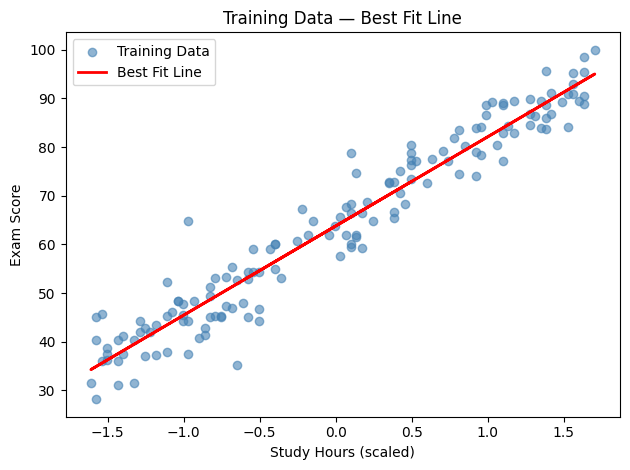

In [28]:
# Training Data — dots + best fit line

plt.scatter(X_train, y_train, color="steelblue", alpha=0.6, label="Training Data")
plt.plot(X_train, model.predict(X_train), color="red", linewidth=2, label="Best Fit Line")
plt.xlabel("Study Hours (scaled)")
plt.ylabel("Exam Score")
plt.title("Training Data — Best Fit Line")
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 8 — Predictions on Test Data

    predicted Exam Score = Intercept + Coef × (X_test)
    
    model.predict(X_test)
    → takes each row from X_test (scaled study hours)
    → plugs it into ŷ = intercept + coef × X
    → returns predicted exam score for each student

In [29]:
# Predict exam scores for test students
y_predicted = model.predict(X_test)

In [30]:
# See first 5 predictions vs actual scores
print("Predicted  :", y_predicted[:5].round(2))
print("Actual     :", y_test.values[:5])

Predicted  : [64.33 44.74 71.52 48.66 34.29]
Actual     : [60.5 53.8 65.6 47.1 34.5]


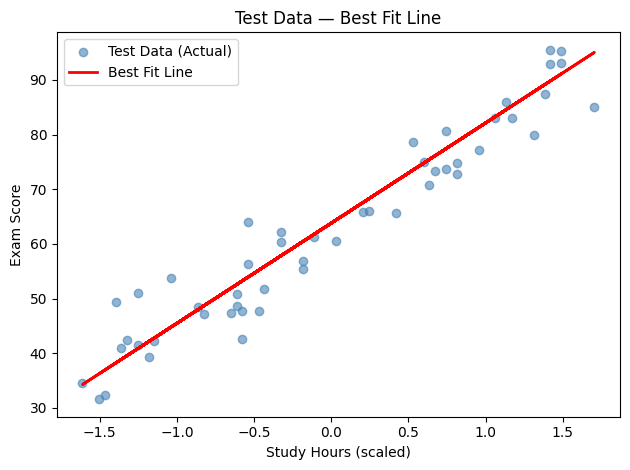

In [31]:
# Plot Test Data — dots + line
plt.scatter(X_test, y_test, color="steelblue", alpha=0.6, label="Test Data (Actual)")
plt.plot(X_test, model.predict(X_test), color="red", linewidth=2, label="Best Fit Line")
plt.xlabel("Study Hours (scaled)")
plt.ylabel("Exam Score")
plt.title("Test Data — Best Fit Line")
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 9 — Performance Metrics

    We compare  y_predicted  (what model said)  vs  y_test  (real answers)

    MAE   →  Mean Absolute Error
            average of  |actual − predicted|
            in the same unit as Y  (exam marks)
            lower is better

    MSE   →  Mean Squared Error
            average of  (actual − predicted)²
            penalizes large errors more heavily
            lower is better

    RMSE  →  Root Mean Squared Error
            square root of MSE
            brings error back to original unit  (exam marks)
            easier to understand than MSE
            lower is better

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [36]:
mse  = mean_squared_error(y_test, y_predicted)   # pass real first, predicted second
mae  = mean_absolute_error(y_test, y_predicted)
rmse = np.sqrt(mse)

print("MSE  : ", mse)
print("MAE  : ", mae)
print("RMSE : ", rmse)

# RMSE tells you : on average the model's prediction is off by RMSE marks

MSE  :  25.003428147697065
MAE  :  4.068429196107336
RMSE :  5.000342803018316


---
## Step 10 — R² Score and Adjusted R²

    R²  →  how much of the variation in Y is explained by X
    
    R² = 1.0  →  perfect  ( model explains everything )
    R² = 0.9  →  model explains 90% of the variation
    R² = 0.5  →  explains only 50%
    R² = 0    →  same as just predicting the mean every time
    R² < 0    →  worse than predicting the mean
    
    Adjusted R²  →  same as R² but penalizes unnecessary features
    For Simple Linear Regression  →  R² and Adjusted R² are almost same
    Adjusted R² is more useful in Multiple Linear Regression

In [38]:
from sklearn.metrics import r2_score

In [39]:
score = r2_score(y_test, y_predicted)
print(score)

# example: 0.93 means model explains 93% of variation in exam scores

0.9206500704489602


---

$$
\text{Adjusted } R^2 = 1 - \frac{(1 - R^2)(n - 1)}{n - k - 1}
$$

where  `n` = number of test samples  and  `k` = number of features

In [40]:
from sklearn.metrics import r2_score

# Step 1 : Normal R² calculate karo
r2 = r2_score(y_test, y_predicted)

# Step 2 : n and k nikalo
n = X_test.shape[0]   # number of rows (test samples)
k = X_test.shape[1]   # number of features (columns)

# Step 3 : Adjusted R² formula apply karo
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print(f"R² Score          : {r2:.4f}")
print(f"Adjusted R² Score : {adjusted_r2:.4f}")

# For Simple Linear Regression both are almost identical
# because we only have 1 feature

R² Score          : 0.9207
Adjusted R² Score : 0.9190


---
## 🎯 Summary

| Step | What We Did |
|------|-------------|
| Load | 200 rows — Study_Hours and Exam_Score |
| EDA | Scatter plot + corr() — strong positive correlation ~0.96 |
| X and Y | X = Study_Hours as DataFrame, Y = Exam_Score as Series |
| Split | 75% train, 25% test — random_state=42 |
| Scaling | StandardScaler — fit_transform on X_train, transform on X_test only |
| Model | LinearRegression — fit(X_train, y_train) |
| Equation | Exam_Score = intercept + coef × Study_Hours_scaled |
| Predict | model.predict(X_test) — plug X_test into equation |
| Metrics | MAE, MSE, RMSE — how far off predictions are |
| R² | How much variance in Y is explained by X |
